# Prompt Jitter EDA

Quick notebook for visualizing prompt jitter on decoded ultrasound images and masks.

No random seeds are set: rerunning the sample cell picks a new image, and rerunning the plotting cell resamples jitter directions.


In [51]:
from __future__ import annotations

import argparse
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

ROOT = Path.cwd()
if not (ROOT / "datasets").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from benchmarks.ultrasam_inference import perturb_bboxes, point_prompts_from_masks
from datasets.common import bbox_from_binary_mask, bbox_masks_from_mask, ensure_three_channels, normalize_to_uint8
from datasets.loader import add_dataset_args, build_decoder_from_args, default_dataset_root


## Settings

In [52]:
datasets_json = ROOT / "datasets" / "datasets.json"
available_datasets = sorted(json.loads(datasets_json.read_text())["labels"])

# Leave as None to randomly sample from available_datasets every time the sample cell is run.
# Set to a dataset key like "blusg" to force one dataset.
dataset = None

# Keep this modest for very large datasets. The selected image is random among scanned non-empty masks.
max_scan = 300

# Prompt reference settings.
bbox_mode = "individual"  # "individual" or "union"
bbox_min_area = 16

# Magnitudes mirror the jitter experiment defaults.
bbox_scale_factors = [0.85, 0.9, 0.95, 1.0, 1.05, 1.10, 1.15]
bbox_translation_fractions = [0.0, 0.025, 0.05, 0.075, 0.10, 0.125, 0.15]
point_prompt_jitter_fractions = [0.0, 0.025, 0.05, 0.075, 0.10, 0.125, 0.15]

# Add dataset-specific loader flags here if needed, e.g. {"busi": ["--busi-categories", "benign,malignant"]}.
extra_dataset_args_by_dataset = {}

available_datasets


['aulid',
 'blusg',
 'busbra',
 'busi',
 'camus',
 'gist514',
 'mmotu',
 'oku',
 'roblus',
 'tnsc2020',
 'ultrabones100k',
 'umud',
 'uns']

## Load A Random Sample

In [53]:
def decoder_for_dataset(dataset: str, dataset_root: Path):
    parser = argparse.ArgumentParser()
    add_dataset_args(parser)
    args = parser.parse_args([
        "--dataset", dataset,
        "--dataset-root", str(dataset_root),
        "--no-auto-download",
        *extra_dataset_args_by_dataset.get(dataset, []),
    ])
    return build_decoder_from_args(args)


def random_dataset() -> str:
    if dataset is not None:
        return dataset
    rng = np.random.default_rng()
    return available_datasets[int(rng.integers(0, len(available_datasets)))]


def random_non_empty_sample(dataset: str, dataset_root: Path, max_scan: int | None = None):
    rng = np.random.default_rng()
    decoder = decoder_for_dataset(dataset, dataset_root)
    candidates = []
    for sample in decoder.iter_samples(max_samples=max_scan):
        mask = np.asarray(sample.mask).astype(bool)
        if mask.any():
            candidates.append(sample)
    if not candidates:
        raise RuntimeError(f"No non-empty masks found for {dataset!r} within max_scan={max_scan}.")
    return candidates[int(rng.integers(0, len(candidates)))]


selected_dataset = random_dataset()
dataset_root = ROOT / default_dataset_root(selected_dataset)
sample = random_non_empty_sample(selected_dataset, dataset_root, max_scan=max_scan)
image = ensure_three_channels(normalize_to_uint8(sample.image))
mask = np.asarray(sample.mask).astype(bool)
print(selected_dataset)
print(sample.sample_id)
print(sample.metadata)


tnsc2020
1482
{'raw_file': '1482.PNG', 'category': 0}


## Jitter Helpers

These helpers only gather components and call the same jitter functions used by `benchmarks/ultrasam_inference.py`. All panels show the original mask. Dashed yellow is the baseline bbox, cyan is the baseline centroid point, and magenta shows the jittered prompt for the current column.


In [54]:
def component_masks(mask: np.ndarray) -> list[np.ndarray]:
    return bbox_masks_from_mask(mask, mode=bbox_mode, min_area=bbox_min_area)


def component_bboxes(components: list[np.ndarray]) -> np.ndarray:
    boxes = [bbox_from_binary_mask(component, padding=0) for component in components]
    boxes = [box for box in boxes if box is not None]
    if not boxes:
        return np.empty((0, 4), dtype=np.int32)
    return np.stack(boxes).astype(np.int32)


def scaled_bboxes(boxes: np.ndarray, scale_factor: float, image_shape: tuple[int, int]) -> np.ndarray:
    height, width = image_shape
    return np.asarray(
        perturb_bboxes(
            [box for box in boxes],
            scale_factor=scale_factor,
            translation_fraction=0.0,
            height=height,
            width=width,
            rng=None,
        ),
        dtype=np.int32,
    )


def translated_bboxes(boxes: np.ndarray, translation_fraction: float, image_shape: tuple[int, int]) -> np.ndarray:
    height, width = image_shape
    return np.asarray(
        perturb_bboxes(
            [box for box in boxes],
            scale_factor=1.0,
            translation_fraction=translation_fraction,
            height=height,
            width=width,
            rng=None,
        ),
        dtype=np.int32,
    )


def jittered_points(components: list[np.ndarray], jitter_fraction: float) -> np.ndarray:
    return point_prompts_from_masks(
        components,
        jitter_fraction=jitter_fraction,
        seed=None,
        image_id=0,
    )



## Visualize Prompt Jitter

Rerun this cell to resample translation and point-jitter directions on the same image. Rerun the previous sample cell to choose a new image.


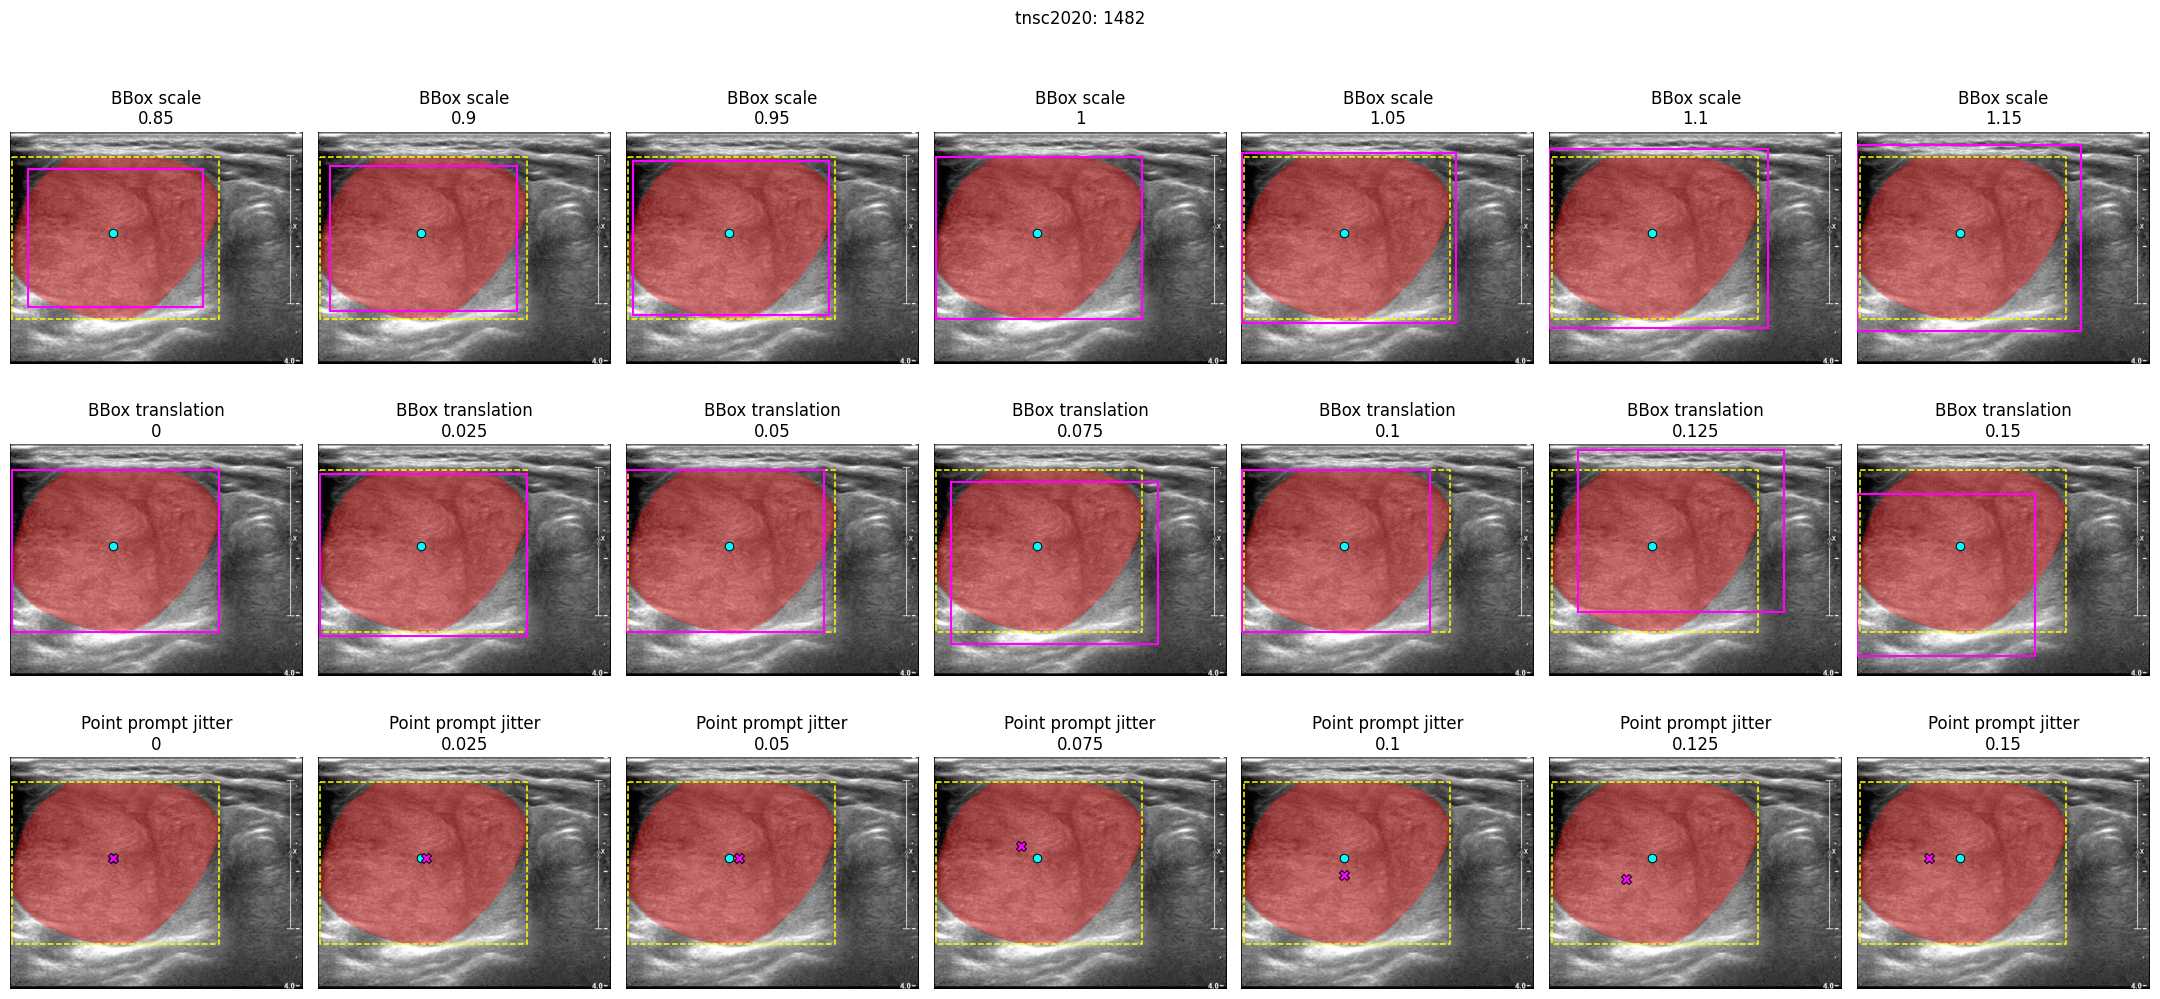

In [55]:
def mask_overlay(mask: np.ndarray, color=(1.0, 0.0, 0.0), alpha: float = 0.35) -> np.ndarray:
    mask_bool = np.asarray(mask).astype(bool)
    overlay = np.zeros((*mask_bool.shape, 4), dtype=np.float32)
    overlay[mask_bool, :3] = color
    overlay[mask_bool, 3] = alpha
    return overlay


def draw_boxes(axis, boxes: np.ndarray, *, color: str, linestyle: str, linewidth: float):
    for x0, y0, x1, y1 in boxes:
        axis.add_patch(
            Rectangle(
                (x0, y0),
                max(float(x1 - x0), 1.0),
                max(float(y1 - y0), 1.0),
                fill=False,
                edgecolor=color,
                linestyle=linestyle,
                linewidth=linewidth,
            )
        )


def draw_points(axis, points: np.ndarray, *, color: str, marker: str, size: float):
    if len(points) == 0:
        return
    axis.scatter(
        points[:, 0],
        points[:, 1],
        s=size,
        c=color,
        marker=marker,
        edgecolors="black",
        linewidths=0.7,
    )


def draw_prompt_panel(axis, title: str, *, boxes: np.ndarray | None = None, points: np.ndarray | None = None):
    axis.imshow(image)
    axis.imshow(mask_overlay(mask))
    draw_boxes(axis, baseline_boxes, color="yellow", linestyle="--", linewidth=1.1)
    draw_points(axis, baseline_points, color="cyan", marker="o", size=38)
    if boxes is not None:
        draw_boxes(axis, boxes, color="magenta", linestyle="-", linewidth=1.5)
    if points is not None:
        draw_points(axis, points, color="magenta", marker="X", size=52)
    axis.set_title(title)
    axis.axis("off")


components = component_masks(mask)
baseline_boxes = component_bboxes(components)
baseline_points = jittered_points(components, 0.0)
image_shape = mask.shape[:2]

rows = [
    ("BBox scale", bbox_scale_factors),
    ("BBox translation", bbox_translation_fractions),
    ("Point prompt jitter", point_prompt_jitter_fractions),
]
columns = max(len(values) for _, values in rows)
fig, axes = plt.subplots(len(rows), columns, figsize=(3.1 * columns, 3.4 * len(rows)), squeeze=False)

for row_idx, (row_label, values) in enumerate(rows):
    for col_idx in range(columns):
        axis = axes[row_idx, col_idx]
        if col_idx >= len(values):
            axis.axis("off")
            continue
        value = values[col_idx]
        if row_label == "BBox scale":
            boxes = scaled_bboxes(baseline_boxes, value, image_shape)
            draw_prompt_panel(axis, f"{row_label}\n{value:g}", boxes=boxes)
        elif row_label == "BBox translation":
            boxes = translated_bboxes(baseline_boxes, value, image_shape)
            draw_prompt_panel(axis, f"{row_label}\n{value:g}", boxes=boxes)
        else:
            points = jittered_points(components, value)
            draw_prompt_panel(axis, f"{row_label}\n{value:g}", points=points)

fig.suptitle(f"{selected_dataset}: {sample.sample_id}", y=1.02)
fig.tight_layout()
